# LSGO — the term-structure of European diesel

**Sample**: 2019-12-13 → 2026-04-17 · 1 637 trading days · ICE LSGO M1-M12 pre-rolled settlements (`GAS 1!-ICE` … `GAS 12!-ICE`).

**Sample-length caveat — up front, not in a footer.** In-sample window is 2019-12-13 → 2024-12-31 (1 304 days). Out-of-sample is 333 days (≈16 months). Every OOS regime-frequency claim below — including the headline "Crisis 31%" — carries wide error bars at this sample length. **Treat OOS regime statistics as descriptive of an episode, not predictive of a distribution.** The mechanism driving the break (Hormuz crisis + Russian sanctions + freight stress) is a firmer anchor than the percentage.

**What LSGO is in the market**: ICE Low-Sulphur Gasoil — the paper benchmark for European distillate. Every NWE diesel cargo, Med gasoil trade and refining margin ultimately settles against this curve or a derivative. When it moves, everything downstream moves.

**What this notebook argues**:

1. **Backwardation is the default state** of LSGO, not a crisis signal. 68% of full-sample days print M1 > M3.
2. **2025-2026 is a regime break, not an amplification.** Crisis regime hit 31% of OOS days vs 1% of IS days — 31× rate, *on a 16-month OOS window; the direction is unambiguous, the level has wide CIs*. M1-M3 peak 293.75 USD/MT on 2026-04-02 is the widest single print on record.
3. **Volatility tracks structure, not price**. Corr(M1-M6, annualised vol) = 0.77. A tight-curve regime is a high-vol regime.
4. **The Z-score methodology is IS-anchored**. Pre-2025 mean/std as ruler; 2026 prints "off the chart" → axis capped at ±5 for readability; actual peak Z ≈ 140 on 2026-04-02 annotated.
5. **The tails are a regime phenomenon**, not structural. IS excess kurtosis = −0.56 (near-Gaussian); full-sample 62.5. Decomposition matters for risk calibration.

Structured in four sections: (1) term structure + back/contango; (2) anomaly detection + distribution; (3) events + dashboard + CDF regime; (4) HMM probabilistic regime + next-day forecast.

*Methodology register — the HMM work here is a demonstration of quantitative calibration discipline. A physical-flow-intensity dashboard would be a complementary lens for a physical desk, not a replacement for the statistical one. Planned as a Phase I extension when live flow data is sourced.*


In [1]:
import sys

sys.path.insert(0, "..")
from src import ForwardCurveAnalysis

fca = ForwardCurveAnalysis(COMMODITY="LSGO").load().build()

[LSGO] Loaded 1637 rows | 2019-12-13 → 2026-04-17 | 12 contracts (pre-rolled)
[LSGO] Pipeline complete — 1637 rows, pre-rolled ICE series (individual rolls not recoverable)


In [2]:
fca.inspect_contracts();

Contract coverage (LSGO):
  GAS 1!-ICE: 1637 days | 2019-12-13 00:00:00 → 2026-04-17 00:00:00
  GAS 2!-ICE: 1637 days | 2019-12-13 00:00:00 → 2026-04-17 00:00:00
  GAS 3!-ICE: 1637 days | 2019-12-13 00:00:00 → 2026-04-17 00:00:00
  GAS 4!-ICE: 1637 days | 2019-12-13 00:00:00 → 2026-04-17 00:00:00
  GAS 5!-ICE: 1637 days | 2019-12-13 00:00:00 → 2026-04-17 00:00:00
  GAS 6!-ICE: 1637 days | 2019-12-13 00:00:00 → 2026-04-17 00:00:00
  GAS 7!-ICE: 1637 days | 2019-12-13 00:00:00 → 2026-04-17 00:00:00
  GAS 8!-ICE: 1637 days | 2019-12-13 00:00:00 → 2026-04-17 00:00:00
  GAS 9!-ICE: 1380 days | 2020-12-11 00:00:00 → 2026-04-17 00:00:00
  GAS 10!-ICE: 1380 days | 2020-12-11 00:00:00 → 2026-04-17 00:00:00
  GAS 11!-ICE: 1380 days | 2020-12-11 00:00:00 → 2026-04-17 00:00:00
  GAS 12!-ICE: 1380 days | 2020-12-11 00:00:00 → 2026-04-17 00:00:00


In [3]:
fca.validate();

=== VALIDATION SUMMARY — LSGO ===
Observations : 1637
Date range   : 2019-12-13 → 2026-04-17
Roll events  : 0
M1 range     : [455.00, 1367.75] USD/MT

Missing values:
  M1             :   0 ( 0.0%)
  M2             :   0 ( 0.0%)
  M3             :   0 ( 0.0%)
  M6             :   0 ( 0.0%)
  M1_M2          :   0 ( 0.0%)
  M1_M3          :   0 ( 0.0%)
  M1_M6          :   0 ( 0.0%)
  Vol_20D        :  20 ( 1.2%)
  Z_M1_M3        :   0 ( 0.0%)
  Z_M1_M6        :   0 ( 0.0%)

Extreme daily returns (>5%): 24 days
Spread ordering |M1-M3|≥|M1-M2|: 1610/1637 (98.4%)

Status: VALIDATED


In [4]:
calib = fca.calibrate_thresholds(IS_END="2024-12-31")
print(f"Thresholds : {calib['thresholds']}")
print(f"IS regimes : {calib['is_regime_days']}")
print(f"OOS regimes: {calib['oos_regime_days']}")

Thresholds : {'TIGHT': 3.6, 'STRESS': 6.71, 'CRISIS': 8.25}
IS regimes : {'Normal': 1043, 'Tight': 195, 'Stress': 53, 'Crisis': 13, 'N': 1304}
OOS regimes: {'Normal': 165, 'Tight': 52, 'Stress': 12, 'Crisis': 104, 'N': 333}


In [5]:
fca.summary_stats();

                                     LSGO
Backwardation (M1>M3)               68.0%
M1-M3 mean (USD/MT)                  4.60
M1-M6 mean (USD/MT)                  5.97
M1-M3 max (USD/MT)                 293.75
M1-M6 max (USD/MT)                 427.25
Z-score M1-M3 peak                 139.79
Vol peak (annualised)                115%
M1-M3 skewness                       7.67
M1-M3 excess kurtosis               62.50
Corr M1-M3 vs Vol                   0.760
Corr M1-M6 vs Vol                   0.765
Days |Z|>3 (vs 0.3% expected)  101 (6.2%)


## 1. Term structure — price, vol, the curve

Flat price + 20-day realised vol over the full sample, then the daily M1-M12 forward curves (colour-coded by regime) so the reader sees the back/contango oscillation, then the short-dated spreads (M1-M3, M1-M6, M1-M12) as standalone time series. The 2020 COVID window shows contango in its purest form — M6 briefly $30/MT above M1 during the oil-price collapse when nobody wanted prompt barrels. The 2022 and 2025-2026 windows show backwardation at scale, with M1-M3 exceeding $100/MT in April 2026 — physical prompt scarcity priced into the curve shape.


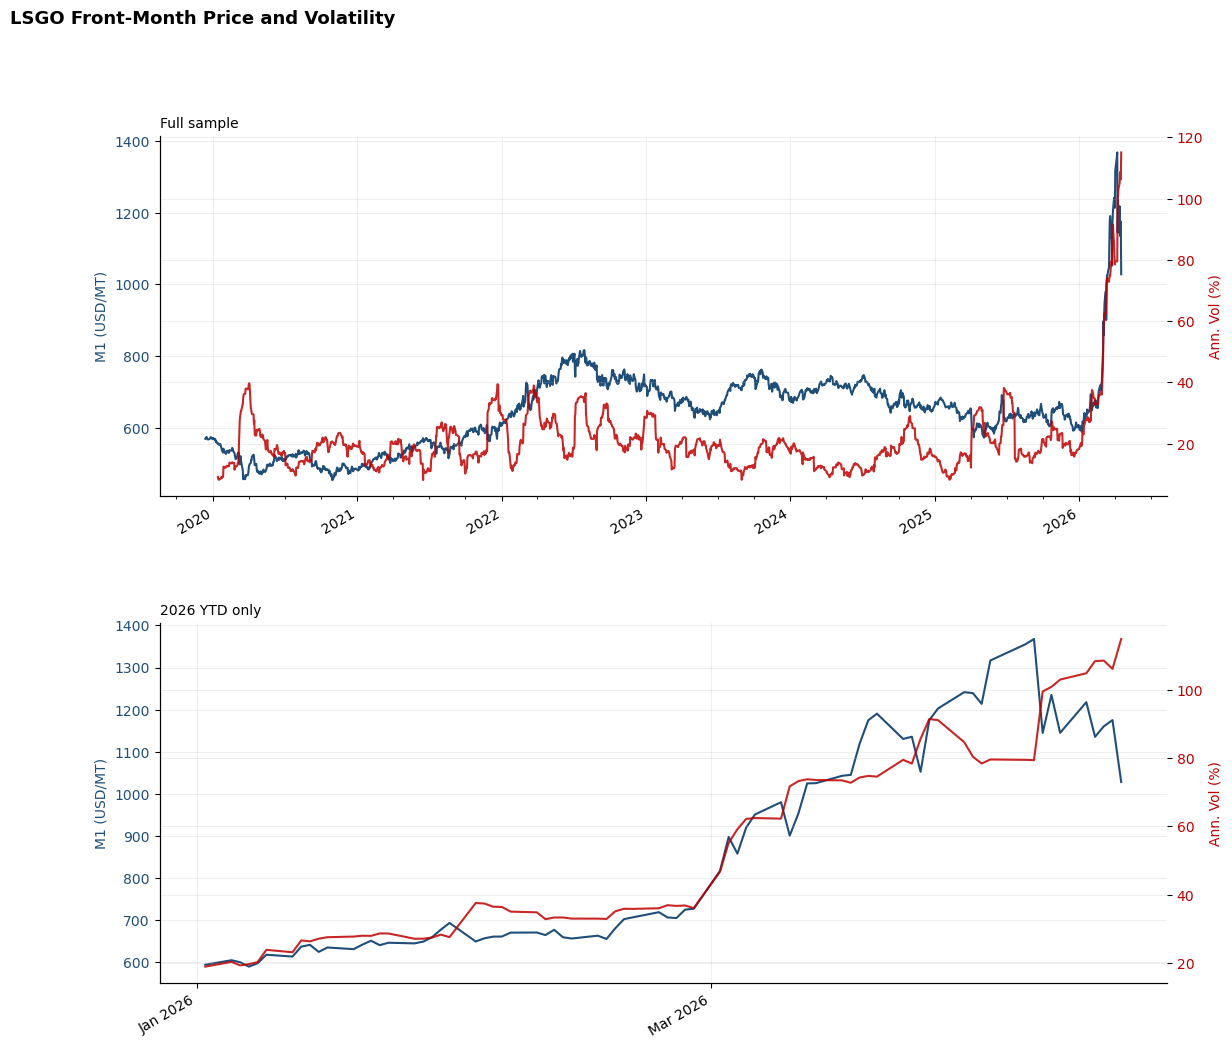

In [6]:
fca.chart_price_vol();

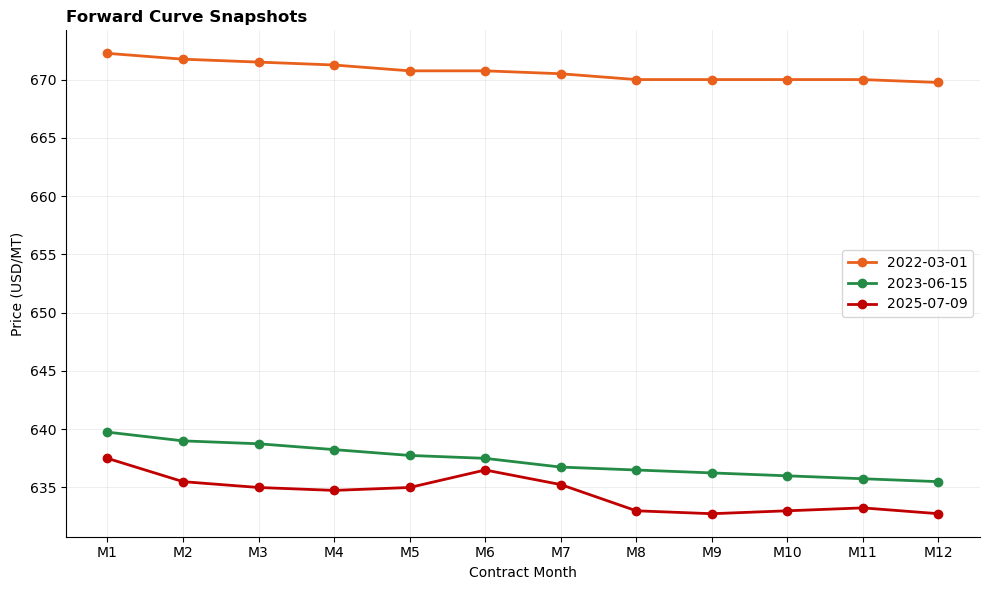

In [7]:
fca.chart_forward_curves();

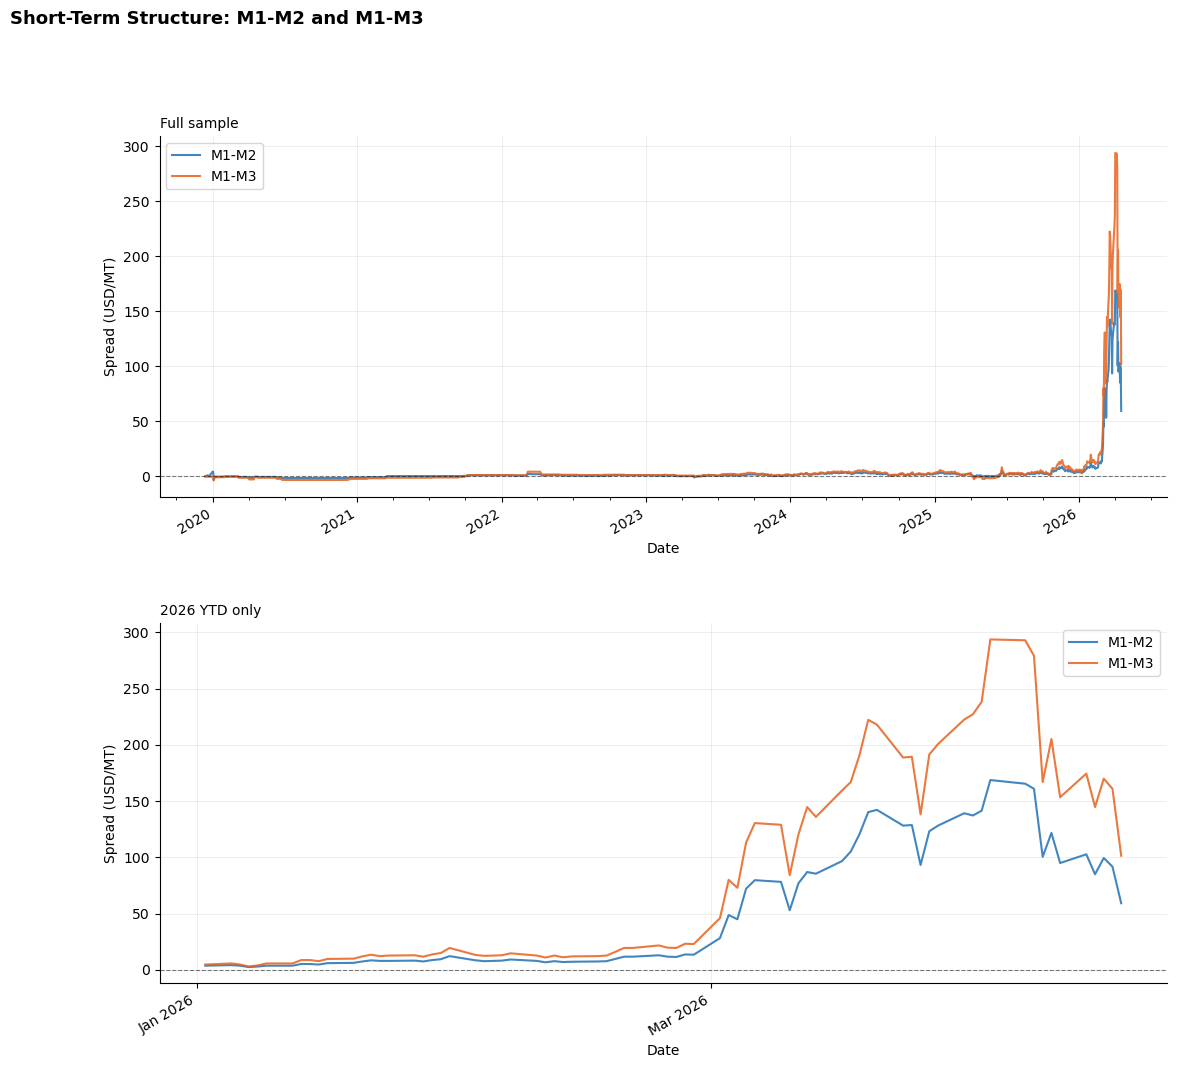

In [8]:
fca.chart_short_structure();

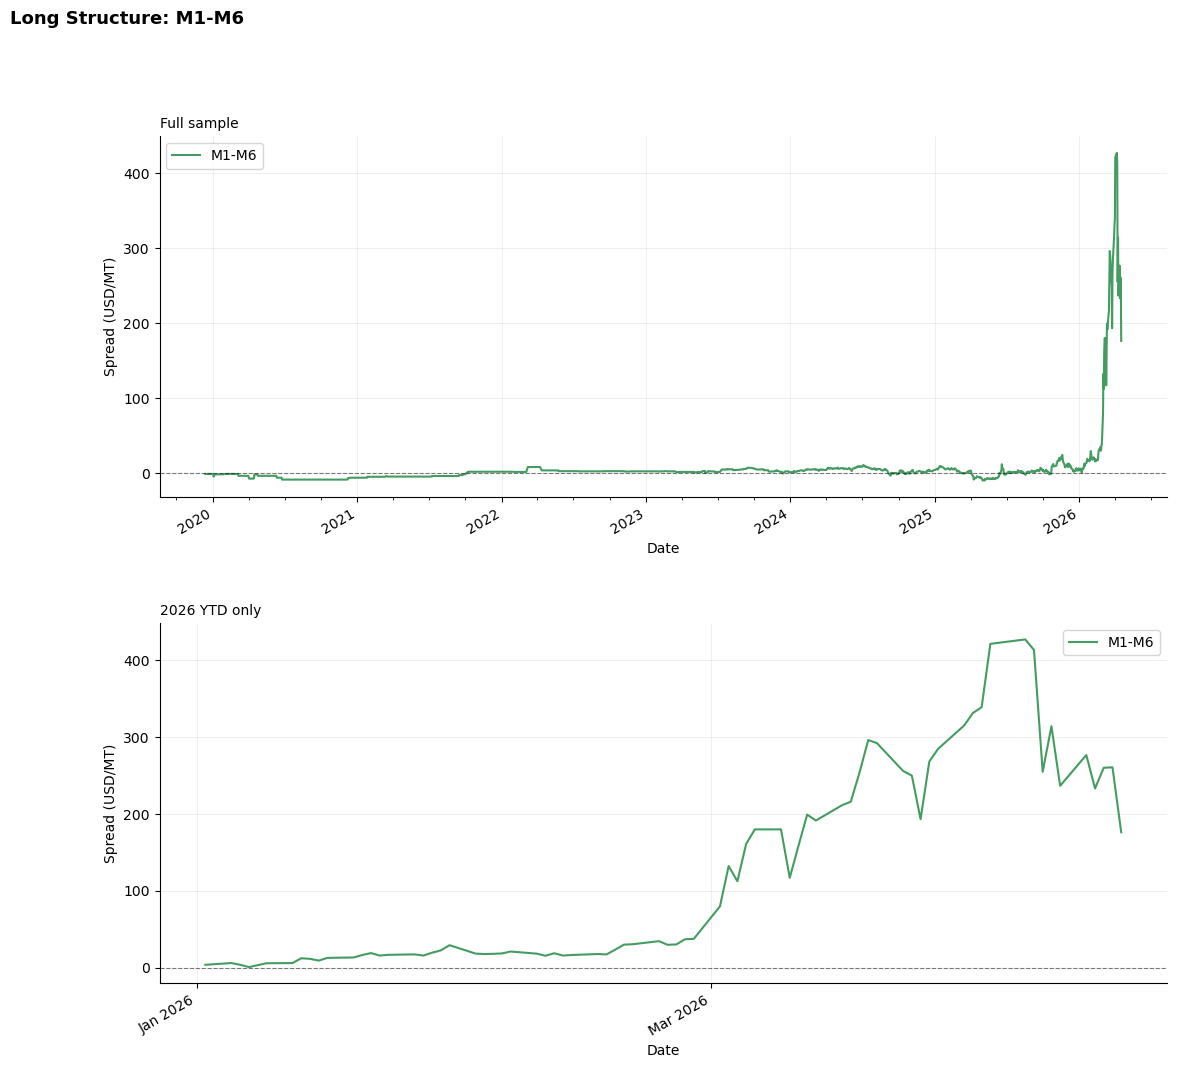

In [9]:
fca.chart_long_structure();

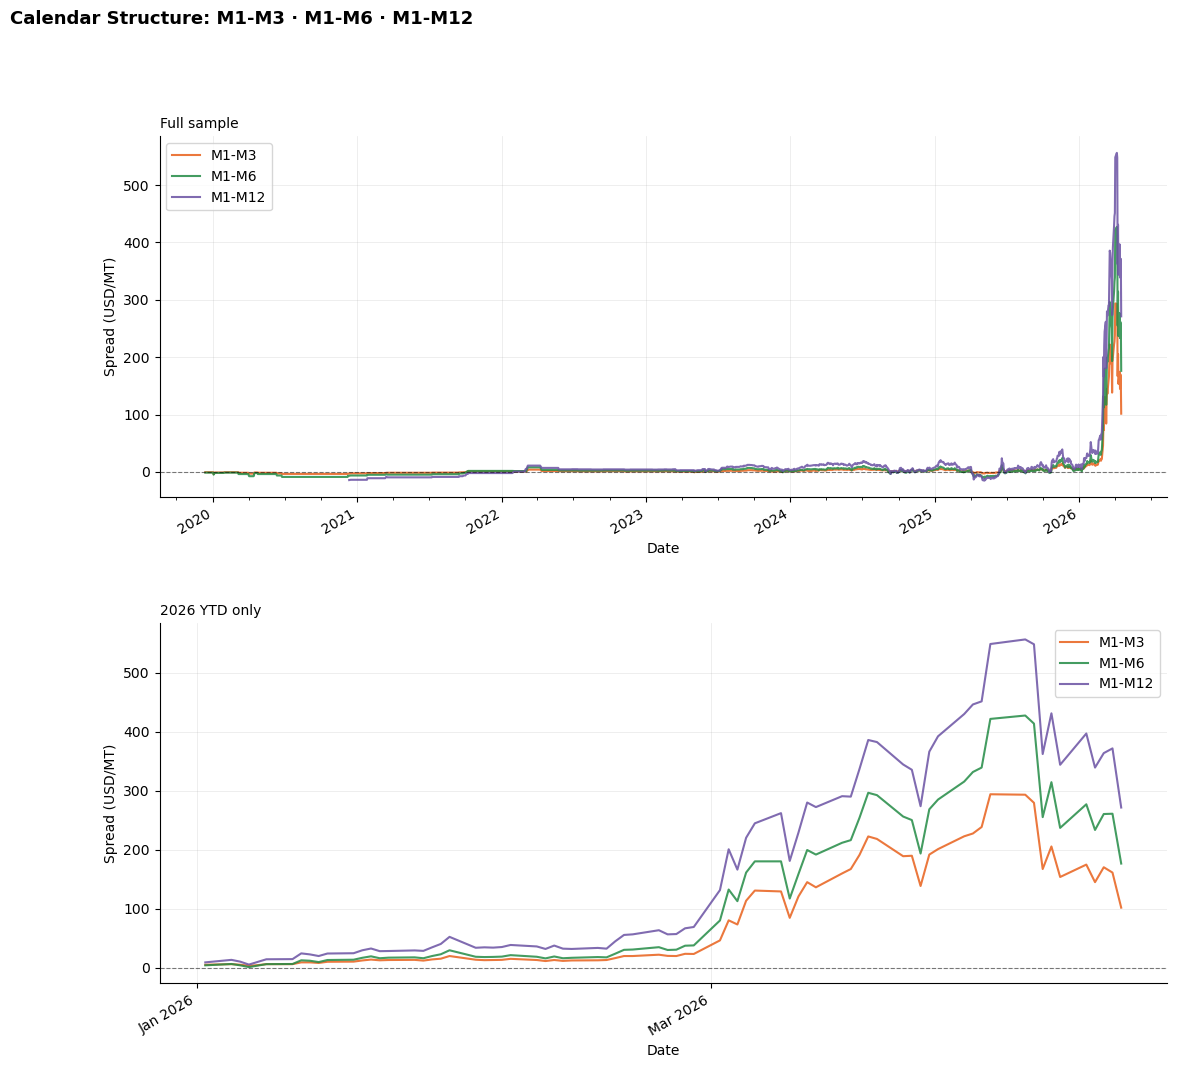

In [10]:
fca.chart_full_strip();

## 2. Anomaly detection — IS-anchored Z-scores and the distribution

Two Z-score panels (M1-M3 and M1-M6) using the pre-2025 mean and std — this removes the rolling-std-floor artefact that would suppress signal in calm windows. The ±5 visual cap keeps the chart readable; actual peak values are annotated. Then the distribution: IS (pre-2025, near-Gaussian, excess kurtosis −0.56) vs OOS (2025+, extreme-tailed, crisis-clustered). This is the cleanest visual for the thesis that 2025-2026 doesn't belong to the same distribution as 2019-2024.


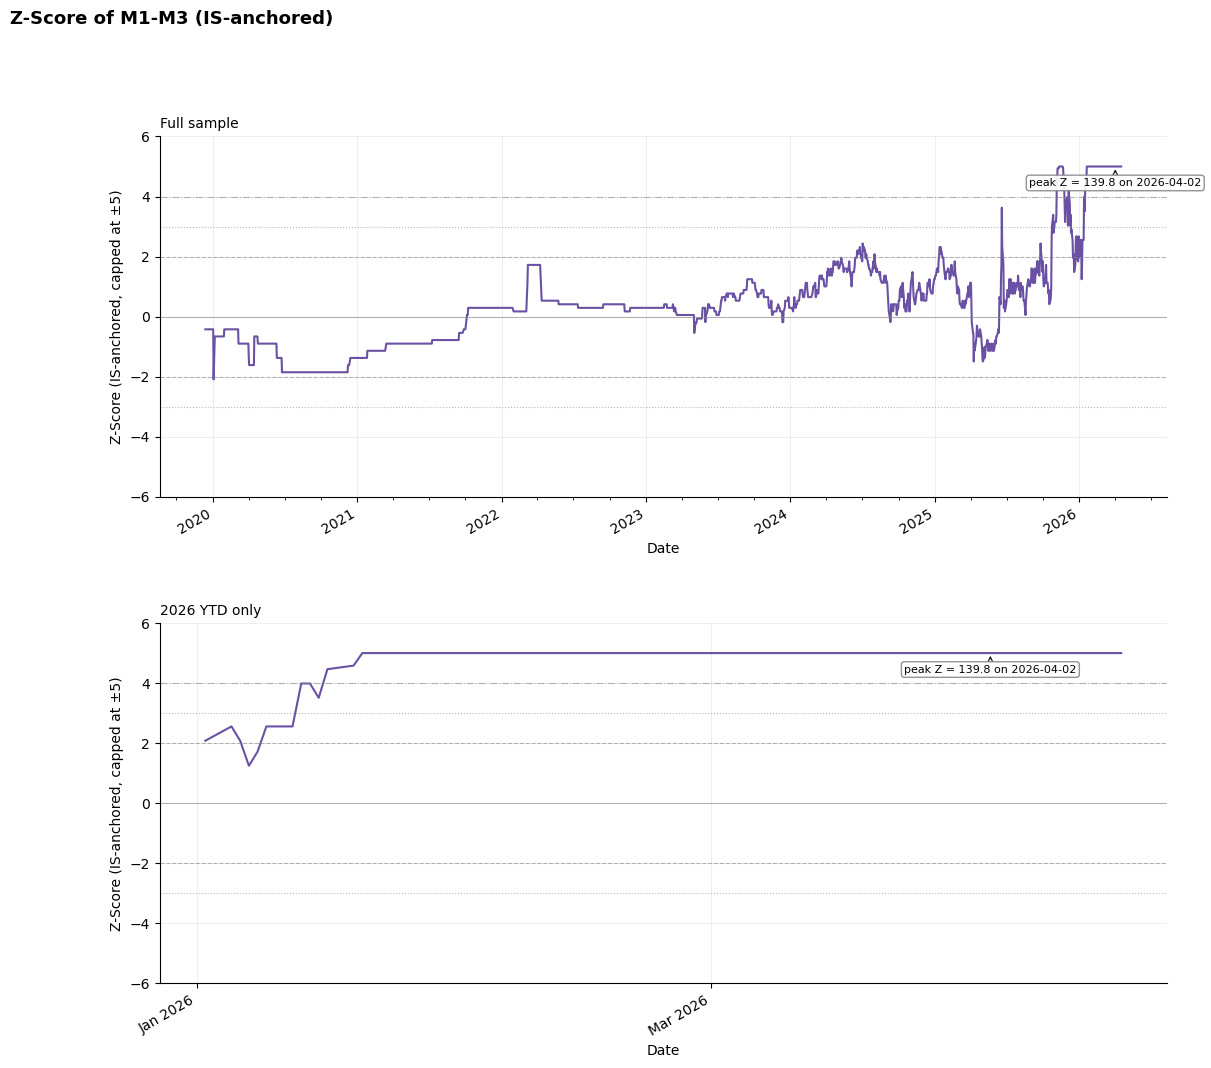

In [11]:
fca.chart_zscore(SPREAD="M1_M3");

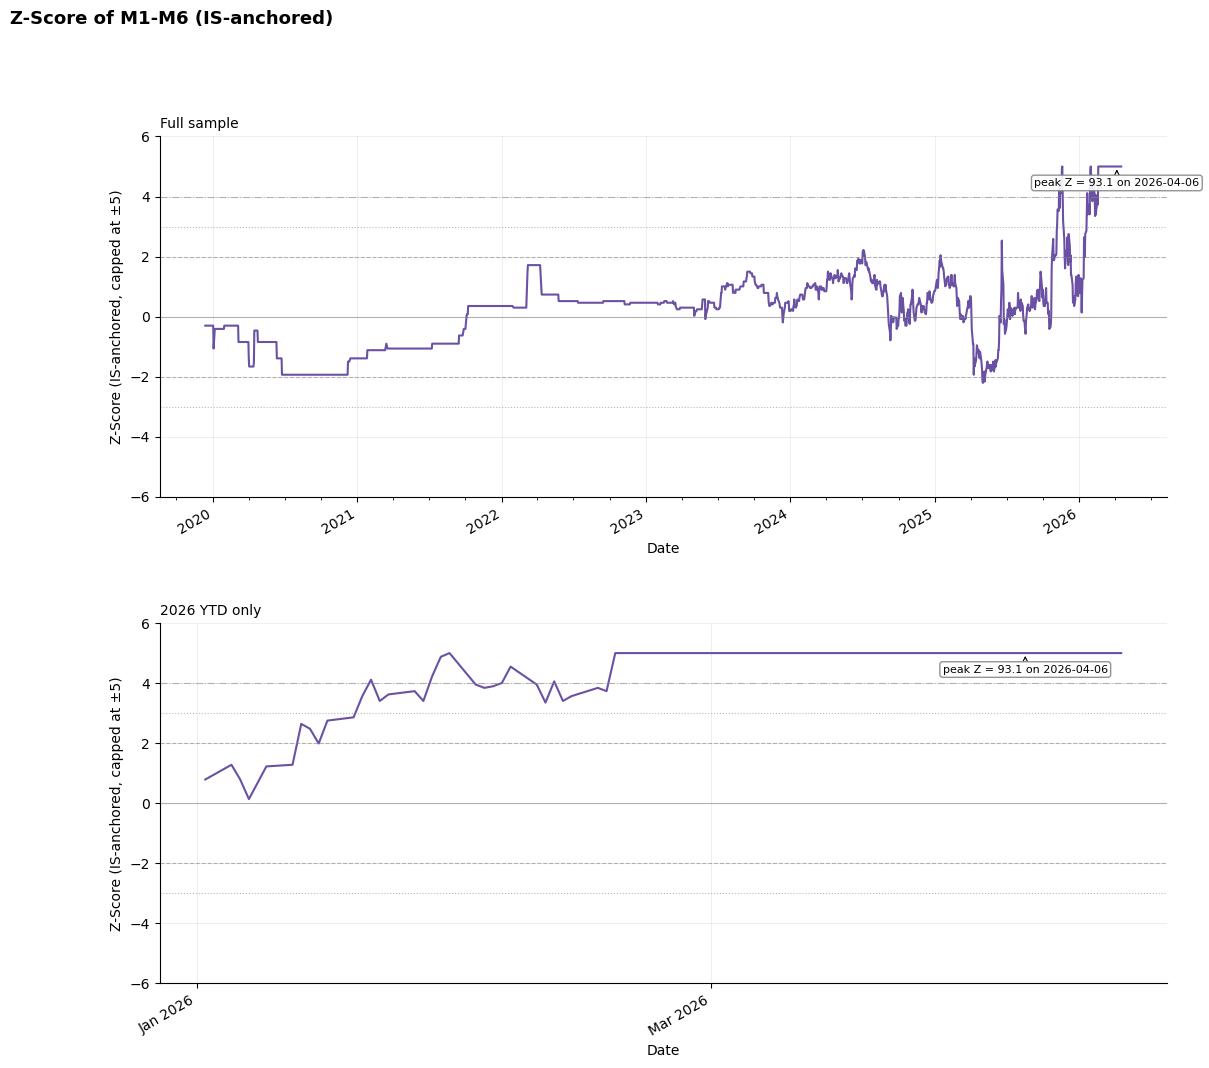

In [12]:
fca.chart_zscore(SPREAD="M1_M6");

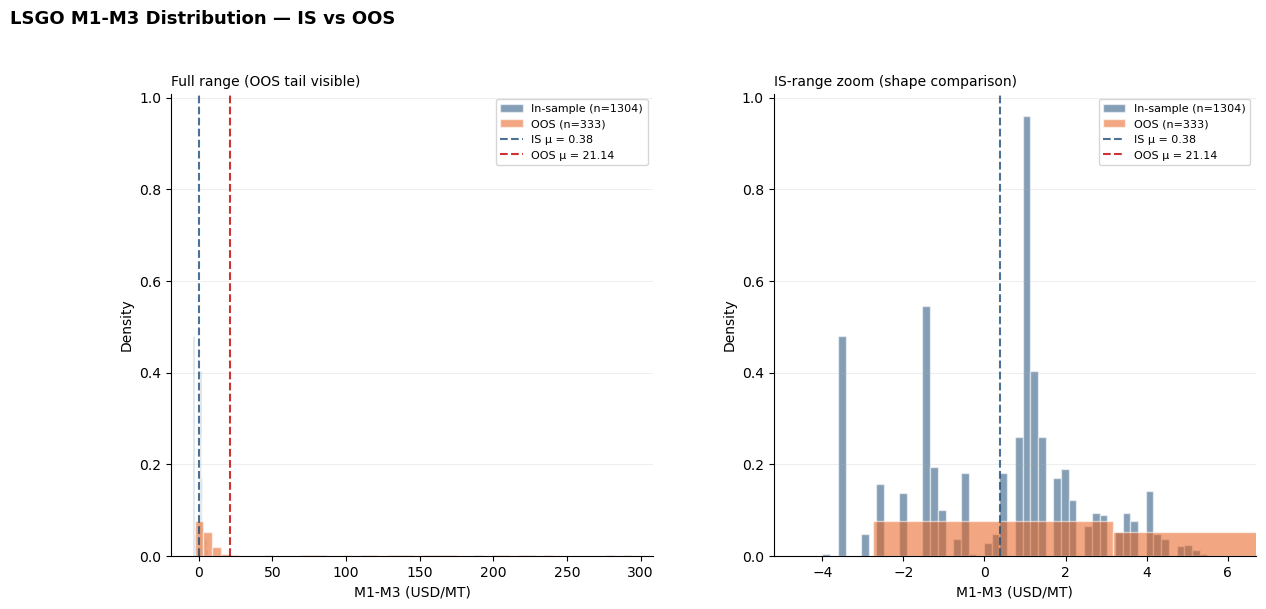

In [13]:
fca.chart_distribution();

## 3. Events, dashboard, regime label

Portfolio-wide event overlay (`../major_dates.yaml`) on the spread series — the 2020 COVID crash, 2022 invasion, 2023 OPEC cuts, 2025-2026 Iran/Hormuz all visible. Then a 4-panel dashboard combining price + M1-M6 + regime + vol for a single-screen snapshot. Regime classification uses the CDF quantiles (80/95/99 on the pre-2025 M1-M6 distribution) — Tight/Stress/Crisis thresholds at 3.60/6.71/8.25 USD/MT.


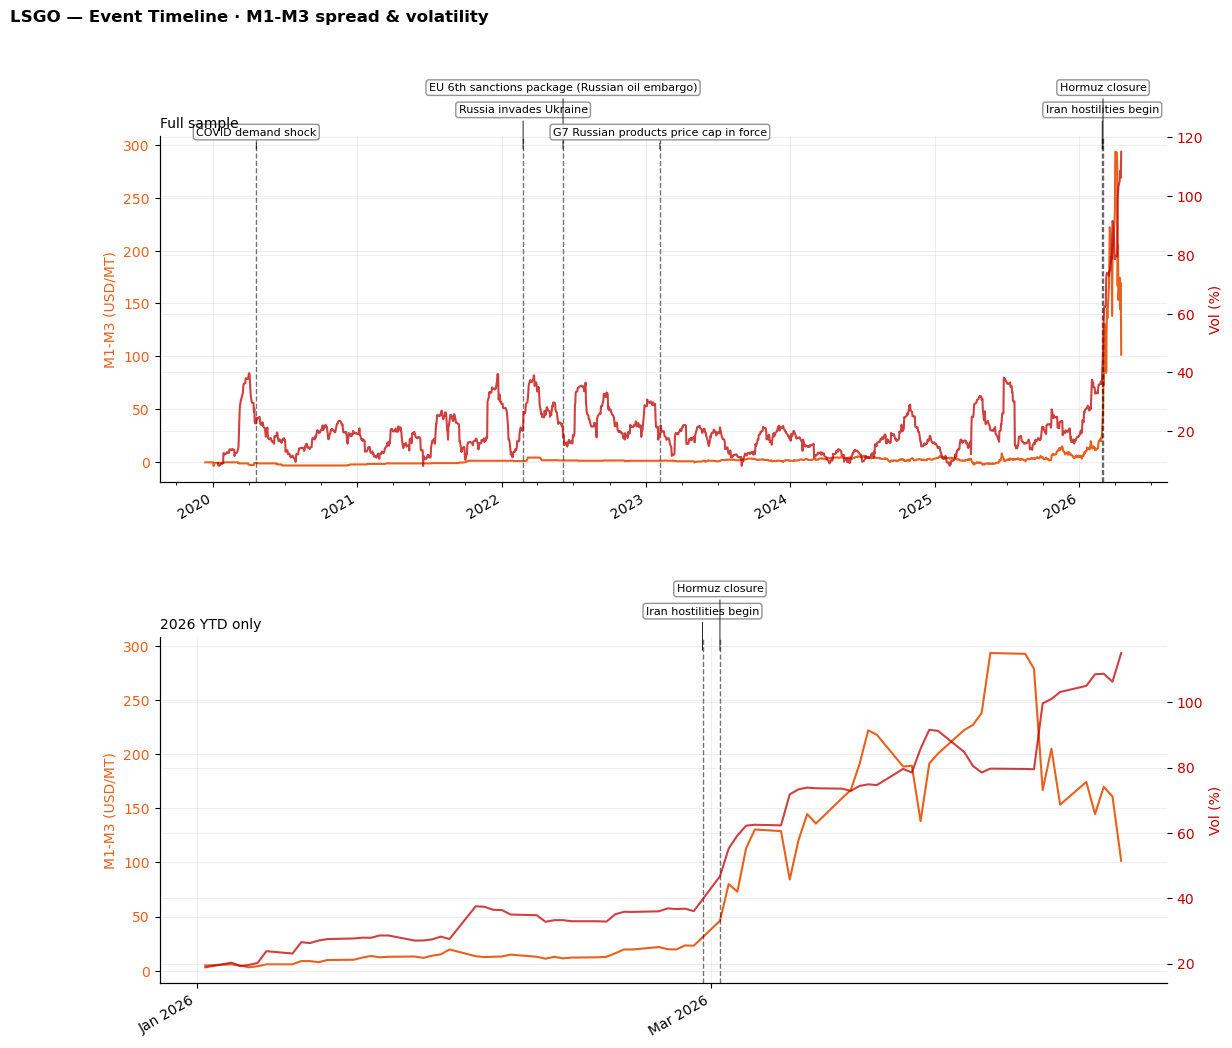

In [14]:
fca.chart_event_timeline();

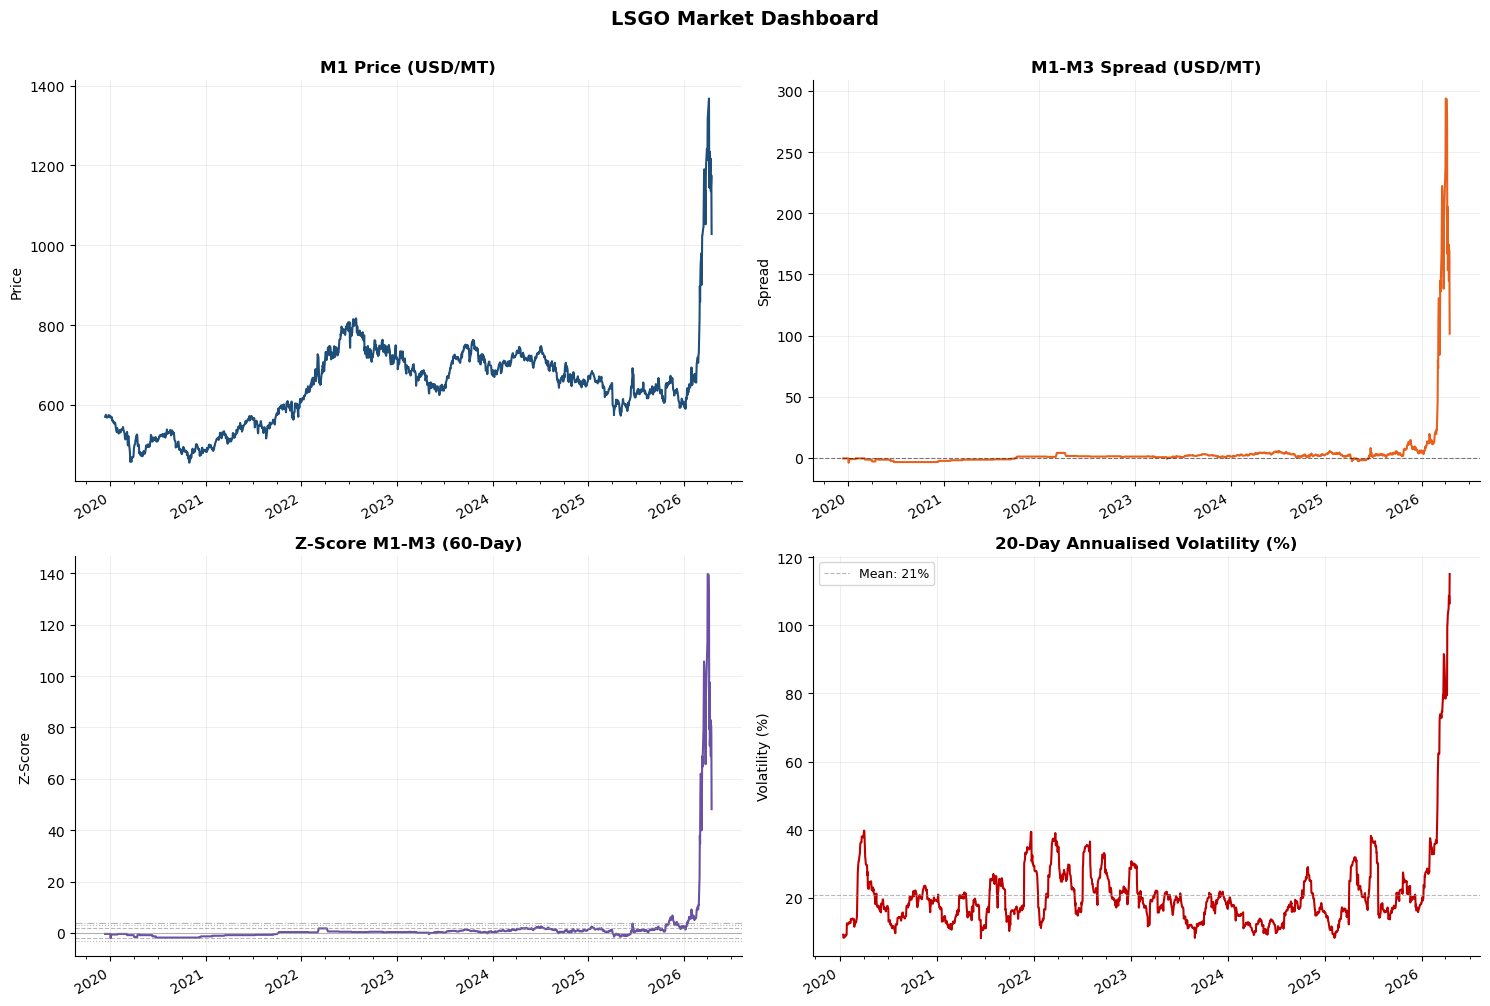

In [15]:
fca.chart_dashboard();

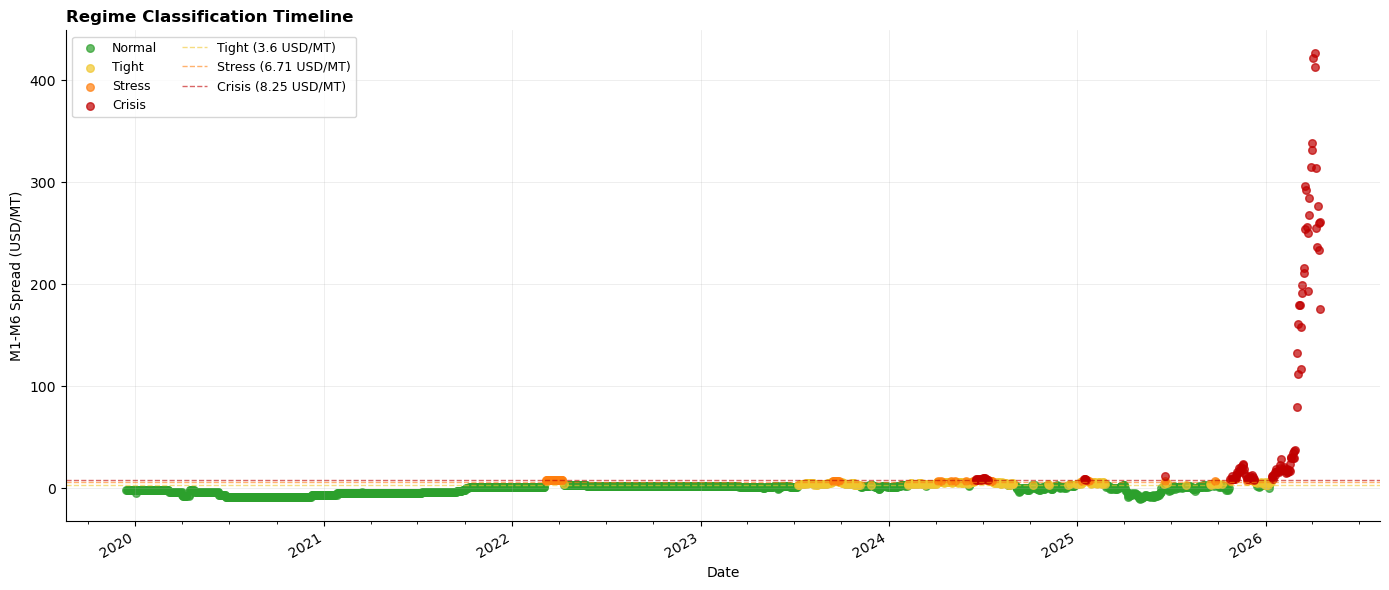

In [16]:
fca.chart_regime();

## 4. HMM probabilistic regime + next-day forecast

The CDF classifier gives hard labels. The HMM gives probabilistic state labels from a 2-state Gaussian emission model plus a transition matrix — useful for boundary prints (a single 8.0 M1-M6 reading sitting on the 8.25 Crisis threshold). We fit the HMM on the full sample because the pre-2025 distribution is unimodal — there is no crisis emission to estimate from IS alone. The next-day forecast below multiplies today's state vector by the transition matrix for +1 to +5 days.


HMM means (by state): [  0.38394918 119.99141059]
HMM std   (by state): [  4.74584099 124.34682903]
Transition matrix:
[[0.99871746 0.00128254]
 [0.01327379 0.98672621]]
IS  P(crisis)>0.5 days: 0/1304 (0.0%)
OOS P(crisis)>0.5 days: 76/333 (22.8%)


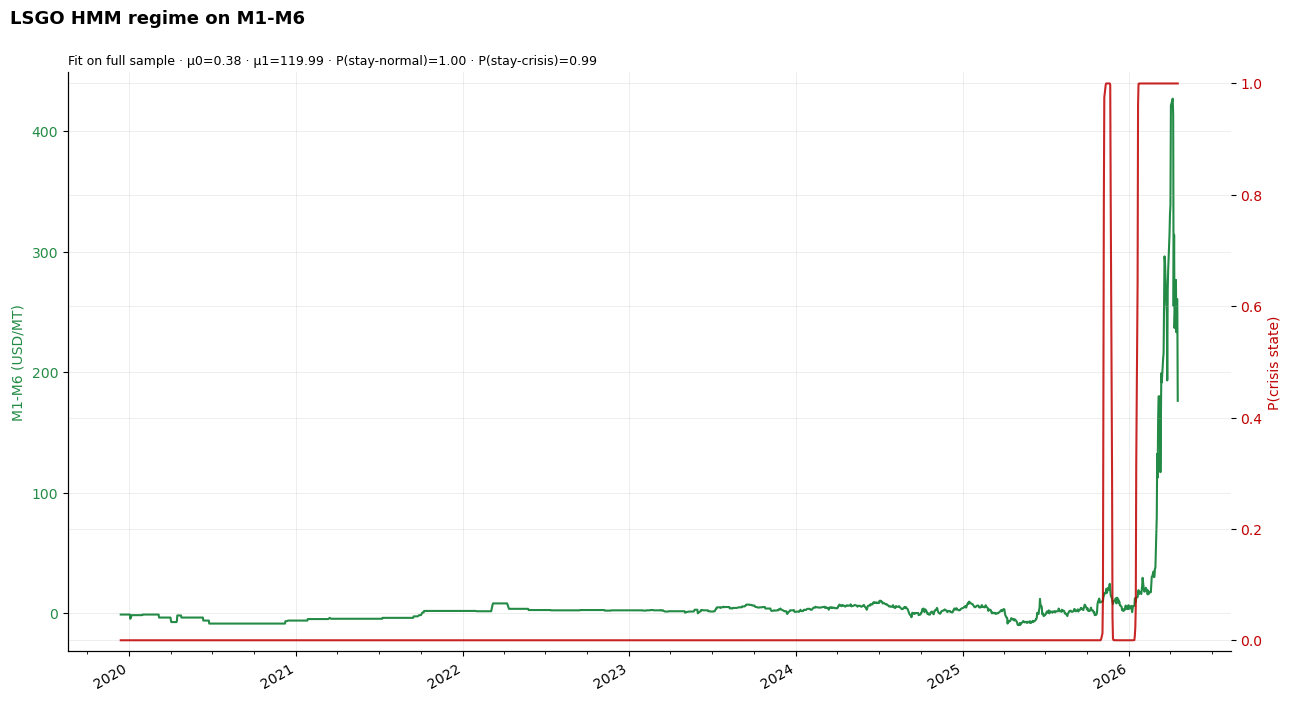

In [17]:
fca.chart_hmm_regime(SPREAD="M1_M6", N_STATES=2);

### Next-day regime forecast (5-day trajectory)


In [18]:
fca.forecast_next_day_regime(HORIZON=5);

As of 2026-04-17:
  today  P(state0)=0.000 · P(state1)=1.000
  +1d    P(state0)=0.013 · P(state1)=0.987
  +2d    P(state0)=0.026 · P(state1)=0.974
  +3d    P(state0)=0.039 · P(state1)=0.961
  +4d    P(state0)=0.052 · P(state1)=0.948
  +5d    P(state0)=0.064 · P(state1)=0.936


## Trader takeaways

- **Default state = backwardation.** 68% full-sample, 85% OOS. Don't read short-dated back as a crisis signal on its own — it's the market's base case for European diesel. *Width* is what matters, not direction.
- **2025-2026 is a regime, not noise.** Crisis state 31% of OOS days, 31× the IS rate. Treat OOS prints as coming from a different distribution when calibrating risk models, not as a continuation of pre-2025.
- **Vol and structure are one signal.** Corr ≈ 0.77 between M1-M6 and annualised vol. A tight-curve regime is a high-vol regime; size position risk accordingly.
- **The 2026 tail is Hormuz.** M1-M3 at 293.75 USD/MT on April 2 lines up precisely with the AG loadings collapse. When the blockade de-escalates, expect a curve re-flattening of similar magnitude — position the OOS exit with an options structure (a paper-only collar on the back months costs little and saves a lot on headline reversal).
- **Cross-market couples non-linearly.** Normal-regime LSGO-Brent ΔM1-M3 correlation ≈ 0.39; crisis-regime 0.81 (see [../notebooks/](../notebooks/)). Static hedges mis-size by 2× when a regime flips — the rolling β is not decorative, it's mandatory.
